In [1]:
!pip install shap xarray netCDF4 eofs cartopy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
from eofs.xarray import Eof

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance

import shap
import warnings
warnings.filterwarnings("ignore")

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tornado_df = pd.read_csv("1950-2021_actual_tornadoes.csv", parse_dates=["date"])

# Filtering for Illinois
il_tornadoes = tornado_df[tornado_df["st"].str.upper() == "IL"]

il_tornadoes["year_month"] = il_tornadoes["date"].dt.to_period("M").dt.to_timestamp()

# Aggregating
monthly_il = il_tornadoes.groupby("year_month").size().reset_index(name="tornado_count")
monthly_il.head()

,year_month,tornado_count
0,1950-01-01,2
1,1950-03-01,1
2,1950-06-01,1
3,1950-07-01,1
4,1950-12-01,3


In [3]:
ds = xr.open_dataset("ATM523MOD4.nc")
if 'valid_time' in ds.coords:
    ds = ds.rename({'valid_time': 'time'})

ds = ds.assign_coords(longitude=((ds.longitude + 360) % 360))
ds = ds.sortby("longitude")

ds_nino34 = ds.sel(latitude=slice(5, -5), longitude=slice(190, 240))

sst = ds_nino34['sst'].load()
sst_clim = sst.groupby('time.month').mean('time')
sst_anom = sst.groupby('time.month') - sst_clim

enso_index = sst_anom.mean(dim=["latitude", "longitude"])

enso_df = enso_index.to_dataframe(name="ENSO").reset_index()
enso_df["year_month"] = pd.to_datetime(enso_df["time"].dt.to_period("M").astype(str))
enso_df = enso_df[["year_month", "ENSO"]]
enso_df.head()

,year_month,ENSO
0,1979-01-01,0.028560
1,1979-02-01,0.158924
2,1979-03-01,0.158143
3,1979-04-01,0.285832
4,1979-05-01,0.244333


In [4]:
merged_df = pd.merge(monthly_il, enso_df, on="year_month", how="inner")

merged_df["month"] = merged_df["year_month"].dt.month
merged_df.head()

,year_month,tornado_count,ENSO,month
0,1979-03-01,1,0.158143,3
1,1979-06-01,3,-0.174418,6
2,1979-07-01,1,-0.299494,7
3,1979-08-01,6,0.161013,8
4,1979-10-01,1,0.045697,10


RMSE: 10.67
Correlation: 0.15


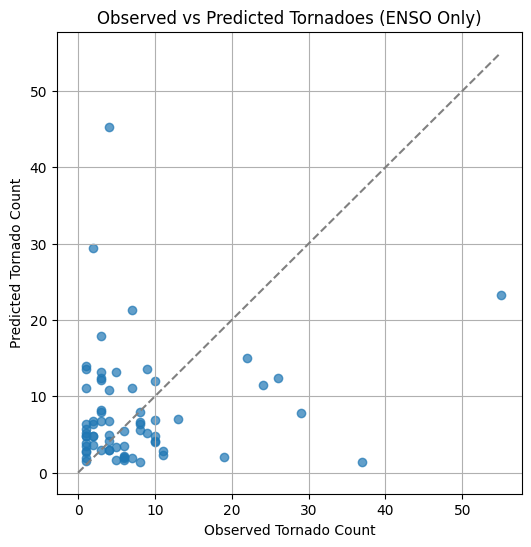

In [5]:
X = merged_df[["ENSO"]]
y = merged_df["tornado_count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
corr = np.corrcoef(y_test, y_pred)[0, 1]

print(f"RMSE: {rmse:.2f}")
print(f"Correlation: {corr:.2f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, max(y_test)], [0, max(y_test)], "--", color="gray")
plt.xlabel("Observed Tornado Count")
plt.ylabel("Predicted Tornado Count")
plt.title("Observed vs Predicted Tornadoes (ENSO Only)")
plt.grid(True)
plt.show()

RMSE with month: 9.94
Correlation with month: 0.07


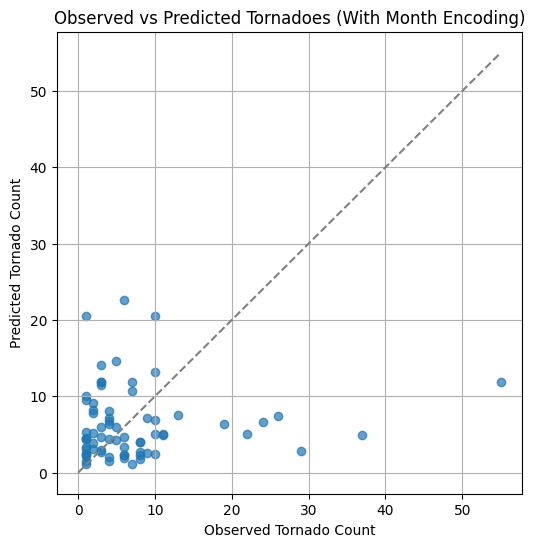

In [6]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop="first", sparse_output=False)
month_encoded = encoder.fit_transform(merged_df[["month"]])
month_df = pd.DataFrame(month_encoded, columns=encoder.get_feature_names_out(["month"]))

merged_encoded = pd.concat([merged_df, month_df], axis=1)

features_extended = ["ENSO"] + list(month_df.columns)
X = merged_encoded[features_extended]
y = merged_encoded["tornado_count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

rf_month = RandomForestRegressor(n_estimators=100, random_state=42)
rf_month.fit(X_train, y_train)
y_pred_month = rf_month.predict(X_test)

rmse_month = np.sqrt(mean_squared_error(y_test, y_pred_month))
corr_month = np.corrcoef(y_test, y_pred_month)[0, 1]

print(f"RMSE with month: {rmse_month:.2f}")
print(f"Correlation with month: {corr_month:.2f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_month, alpha=0.7)
plt.plot([0, max(y_test)], [0, max(y_test)], "--", color="gray")
plt.xlabel("Observed Tornado Count")
plt.ylabel("Predicted Tornado Count")
plt.title("Observed vs Predicted Tornadoes (With Month Encoding)")
plt.grid(True)
plt.show()

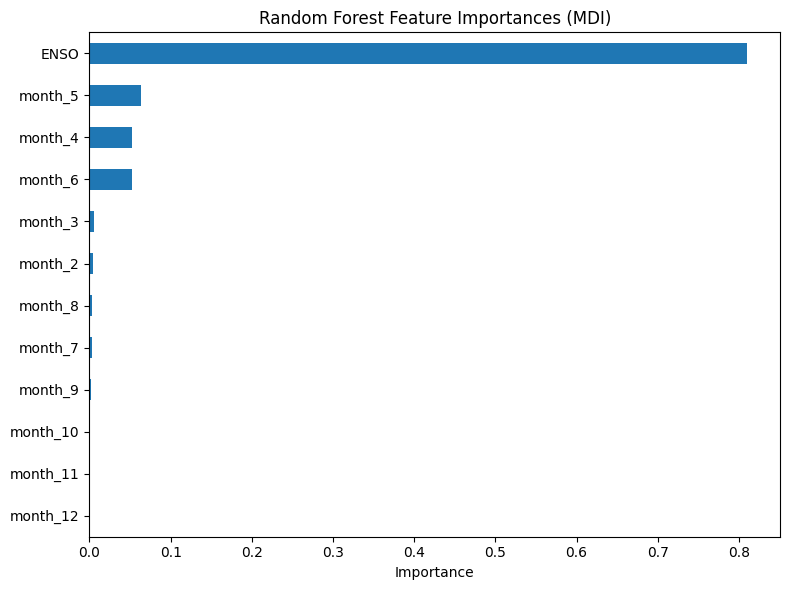

In [7]:
# Mean Decrease in Impurity (MDI) feature importance
importances = pd.Series(rf_month.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot.barh(figsize=(8, 6))
plt.title("Random Forest Feature Importances (MDI)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

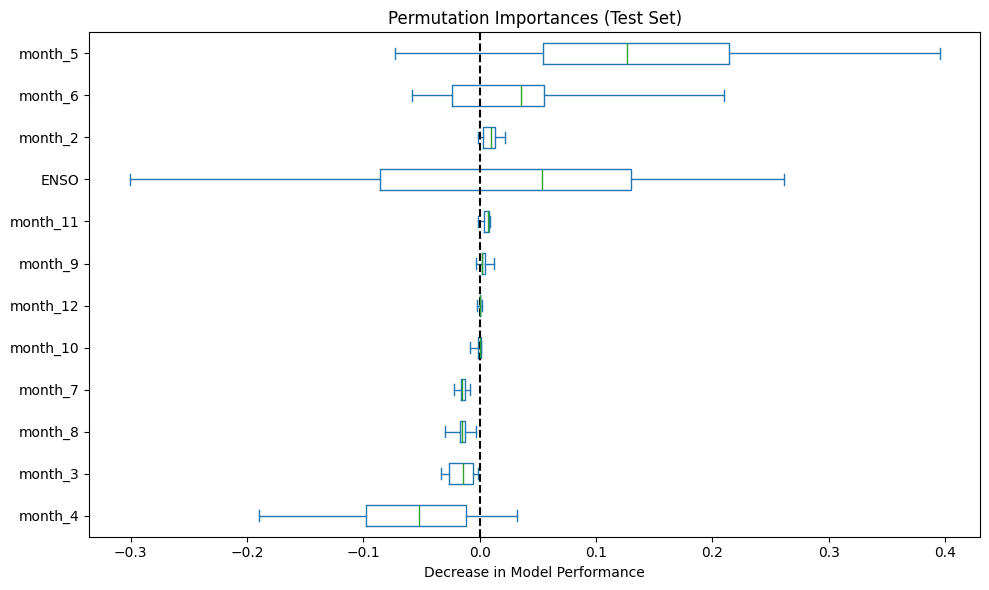

In [8]:
# Permutation importance on test set
perm_result = permutation_importance(
    rf_month, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

perm_sorted_idx = perm_result.importances_mean.argsort()
perm_df = pd.DataFrame(
    perm_result.importances[perm_sorted_idx].T,
    columns=X.columns[perm_sorted_idx]
)

perm_df.plot.box(vert=False, whis=10, figsize=(10, 6))
plt.title("Permutation Importances (Test Set)")
plt.axvline(x=0, color="k", linestyle="--")
plt.xlabel("Decrease in Model Performance")
plt.tight_layout()
plt.show()

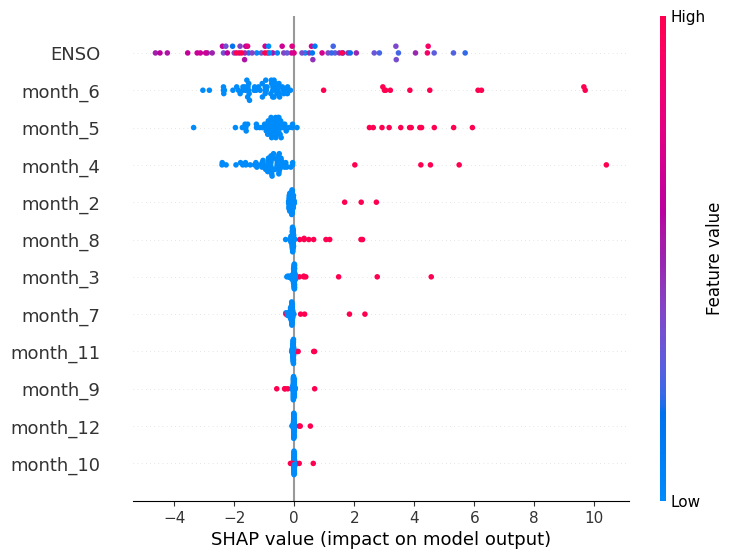

In [9]:
# SHAP explainer and values
explainer = shap.Explainer(rf_month, X_train)
shap_values = explainer(X_test)

# SHAP summary plot
shap.plots.beeswarm(shap_values, max_display=15)

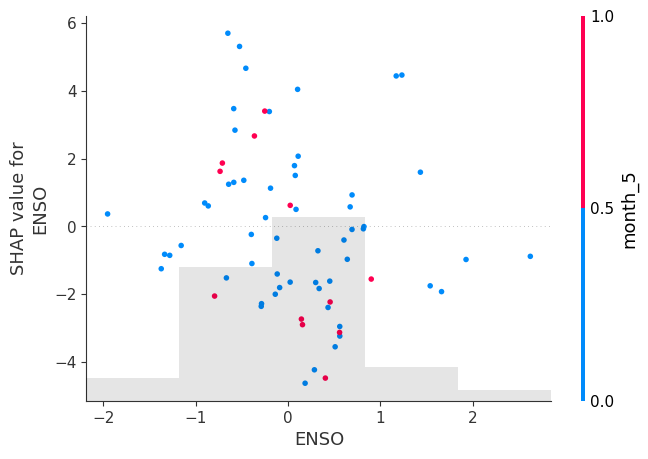

In [10]:
# SHAP dependence plot for ENSO
shap.plots.scatter(shap_values[:, "ENSO"], color=shap_values)

### Model Performance

- The ENSO-only model yields an RMSE of 10.67 and a correlation of 0.15, indicating modest predictive power.
- Adding month encoding slightly improves RMSE to 9.94, but correlation drops to 0.07, suggesting limited linear improvement.
- Both models show wide scatter and underprediction of high tornado counts, especially in active months like May and June.

### Feature Importance (MDI)

- ENSO dominates the model with ~85% of the total importance, far surpassing all month features.
- Month_5 (May), month_4 (April), and month_6 (June) contribute modestly, aligning with peak tornado season.

### Permutation Importance

- Shuffling month_5, month_6, and ENSO causes the largest drops in model performance.
- Several month features (e.g., month_11, month_9) show near-zero or slightly negative importance, suggesting minimal predictive value.

### SHAP Interpretation

- SHAP summary plot confirms ENSO and month_6 as the most impactful features across predictions.
- The SHAP dependence plot for ENSO reveals a nonlinear relationship: higher ENSO values tend to suppress tornado counts, while lower ENSO values are associated with higher predictions.
- The color-coded dependence plot (colored by month_5) shows that ENSO’s suppressive effect is especially pronounced during May, a peak tornado month, suggesting ENSO modulates seasonal extremes.
- Month features show varied but generally weaker influence, with some seasonal clustering (e.g., spring months).

### Final Takeaways

- ENSO provides a strong climate signal, and its influence is most pronounced during peak tornado months.
- Seasonal timing (month) adds useful context but is secondary to ENSO in predictive power.
- The model captures general seasonal patterns but struggles with extremes, a limitation of using only ENSO and month.
